<a href="https://colab.research.google.com/github/jaewoo0108/ml-journey/blob/main/week01-linear-regression-cost/week01_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1: 선형 회귀와 비용 함수 직접 작성

## 이번 주 배운 것
- **지도학습**: 정답(y)이 있는 데이터로 학습
- **선형 회귀 모델**: `f(x) = wx + b`
  - `w`, `b`: 모델 매개변수 (훈련 중 조정)
- **비용 함수**: 예측값과 실제값 차이의 제곱 평균
- **목표**: 비용을 최소화하는 `w`, `b` 찾기

## 오늘 할 일
1. 작은 훈련 세트 만들기
2. 모델 `f(x) = wx + b`를 직접 함수로 짜기
3. 비용 함수를 정의대로 손으로 구현
4. `w`를 바꿔가며 비용이 어떻게 변하는지 시각화
5. sklearn 라이브러리 결과와 비교


In [1]:
# 목적 : 숫자 계산용 numpy, 그래프용 matplotlib 준비

import numpy as np   # 배열/숫자 계산 라이브러리
import matplotlib.pyplot as plt  # 그래프 그리는 라이브러리

훈련 데이터 개수 m = 6


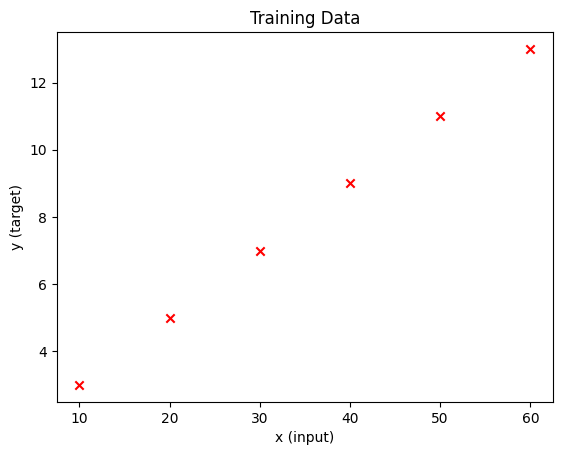

In [2]:
# 목적 : 입력 x_train과 정답 y_train으로 이루어진 훈련 세트 만들기
#(집 크기 데이터 입력 -> 집 값)

x_train = np.array([10, 20, 30, 40, 50, 60])  # 입력값 - 집 크기
y_train = np.array([3, 5, 7, 9, 11, 13])  # 정답값 - 집 가격

m = len(x_train) # 훈련데이터 개수
print(f"훈련 데이터 개수 m = {m}")

# 데이터들 점으로 찍어서 그래프 그리기

plt.scatter(x_train,y_train, color = 'red', marker= 'x')
plt.xlabel('x (input)')
plt.ylabel(('y (target)'))
plt.title('Training Data')
plt.show()


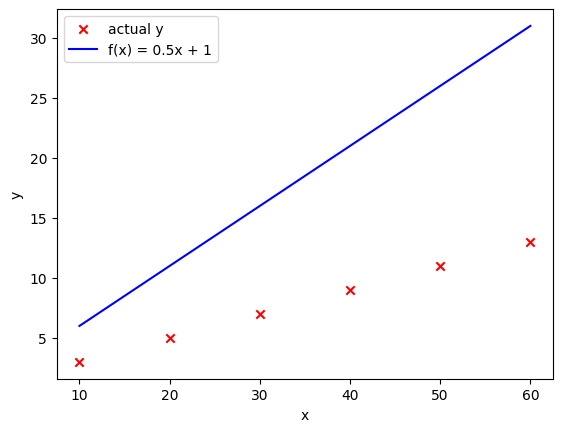

예측값 :y_hat = [ 6. 11. 16. 21. 26. 31.]
실제값 : y = [ 3  5  7  9 11 13]


In [3]:
# 목적 : 선형 모델을 함수로 정의하고 w,b 를 임의로 줬을 때 직선이 어떻게 그려지는 보기

def model(w,x,b):
  """선형 모델 : f(x) = wx + b"""
  return w * x + b

# w,b를 임의로 설정

w = 0.5
b = 1
y_hat = model(w, x_train, b)  # 모델의 예측값

plt.scatter(x_train, y_train, color = 'red', marker = 'x', label = 'actual y')
plt.plot(x_train, y_hat, color = 'blue', label = f'f(x) = {w}x + {b}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

print(f"예측값 :y_hat = {y_hat}")
print(f"실제값 : y = {y_train}")


In [8]:
# 목적 : 비용함수 = (예측값 - 실제값)^2의 평균을 직접 짜서 값 확인

def compute_cost(x, y, w, b):
  """ 비용 함수 J(w,b)"""
  m = len(x)
  total_cost = 0
  for i in range(m):
    y_hat_i = w * x[i] + b
    total_cost = (y_hat_i - y[i]) ** 2
  cost = total_cost / (2 * m)
  return cost

# 위에서 설정한 임의의 매개변수값
print(f"w = 0.5, b = 1일때 cost = {compute_cost(x_train, y_train, 0.5, 1)}")

# 정답에 가까운 매개변수
print(f"w = 0.2, b = 1일때 cost = {compute_cost(x_train, y_train, 0.2, 1)}")


w = 0.5, b = 1일때 cost = 27.0
w = 0.2, b = 1일때 cost = 0.0


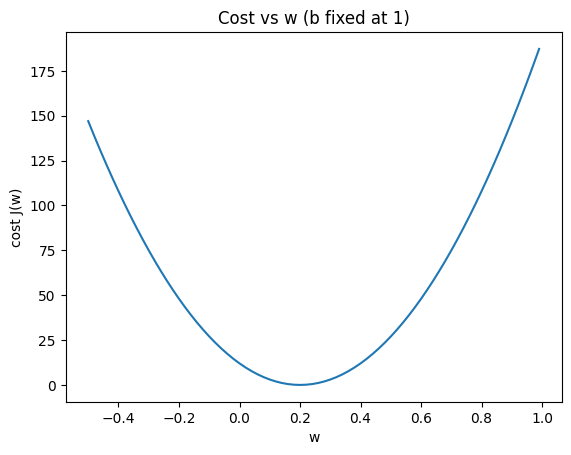

비용이 가장 작은 w = 0.20
그때의 비용 = 0.0000


In [16]:
# 목적: b =1로 고정하고 w를 -0.5 ~ 1.0을 ㅗ바꾸면서 비용 어떻게 변하는지 그래프로 보기

w_values = np.arange(-0.5, 1.0, 0.01)
costs = []

for w in w_values:
  c = compute_cost(x_train, y_train, w, 1)
  costs.append(c)

# 비용 곡선 그리기
plt.plot(w_values, costs)
plt.xlabel('w')
plt.ylabel('cost J(w)')
plt.title('Cost vs w (b fixed at 1)')
plt.show()

# 비용이 가장 작았던 w 찾기
best_w = w_values[np.argmin(costs)]
print(f"비용이 가장 작은 w = {best_w:.2f}")
print(f"그때의 비용 = {min(costs):.4f}")


In [20]:
# 목적 : 라이브러리가 찾은 w,b 와 내가 직접 찾은 결과가 일치하는지 확인

from sklearn.linear_model import LinearRegression

# sklearn은 입력을 (m,n) 2차원 배열로 받음 -> reshape 필요하다
X = x_train.reshape(-1,1)  # (5,) -> (5,1) / Numpy에서 reshape를 할 때 -1은 "행의 개수가 몇 개가 되든 상관 안 할 테니까, 열 크기에 맞춰서 남는 데이터 개수만큼 알아서 꽉 채워라"라는 특수 기호

sklearn_model = LinearRegression()
sklearn_model.fit(X, y_train)

# sklearn이 찾은 매개변수
w_sk = sklearn_model.coef_[0]
b_sk = sklearn_model.intercept_
print(f"sklearn이 찾은 w = {w_sk:.4f}, b = {b_sk:.4f}")

# 찾은 값을 비용 함수에 넣어서 출력 확인
print(f"그 때의 cost = {compute_cost(x_train, y_train, w_sk, b_sk):.6f}")



sklearn이 찾은 w = 0.2000, b = 1.0000
그 때의 cost = 0.000000


도전 과제

- 다른 데이터셋으로 다시: y_train을 살짝 노이즈가 있는 데이터(예: np.array([3.2, 4.7, 7.1, 8.8, 11.3]))로 바꿔서 똑같은 실험을 해봐. sklearn이 찾은 w, b가 여전히 0.2, 1에 가까운지? 비용이 0이 되는지 안 되는지?


훈련 데이터 개수 m = 6


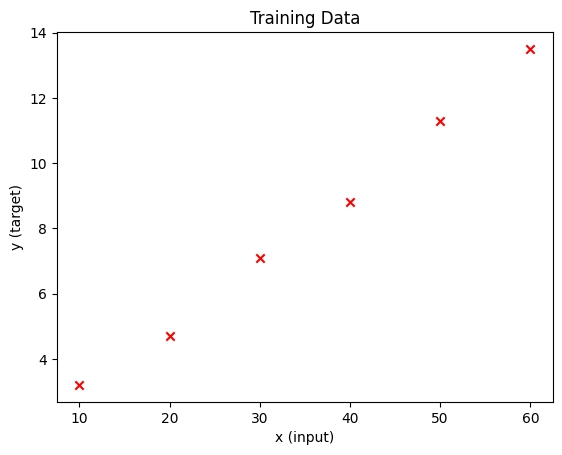

새로 찾은 매개변수 w = 0.2086, b = 0.8000
새로운 비용 = 0.002874


In [24]:
# 목적 : 노이즈를 추가한 데이터셋으로 바꿔서 다시 실험, sklearn에게 최적의 매개변수 찾도록 요구 후 검증

x_train = np.array([10, 20, 30, 40, 50, 60])  # 입력값 - 집 크기
y_train = np.array([3.2, 4.7, 7.1, 8.8, 11.3, 13.5])  # 노이즈 추가된 정답값 - 집 가격

m = len(x_train) # 훈련데이터 개수
print(f"훈련 데이터 개수 m = {m}")

# 데이터들 점으로 찍어서 그래프 그리기

plt.scatter(x_train,y_train, color = 'red', marker= 'x')
plt.xlabel('x (input)')
plt.ylabel(('y (target)'))
plt.title('Training Data')
plt.show()


X0 = x_train.reshape(-1,1)

sklearn_model = LinearRegression()
sklearn_model.fit(X0, y_train)

# sklearn이 찾은 매개변수
w_sk = sklearn_model.coef_[0]
b_sk = sklearn_model.intercept_
print(f"새로 찾은 매개변수 w = {w_sk:.4f}, b = {b_sk:.4f}")

print(f"새로운 비용 = {compute_cost(x_train, y_train, w_sk, b_sk):.6f}")

< 깨달은 것 >

- 노이즈가 추가 됨으로써 해당 데이터셋이 어떤 직선으로도 모든 점을 정확히 지나갈 수 없기 때문에 비용함수의 출력값이 0이 될 수 없다!
- coef_와 intercept_ 는 모델 학습이 끝난후 자기가 찾은 최적의 w와 b값을 저장해놓은 변수 이름이다